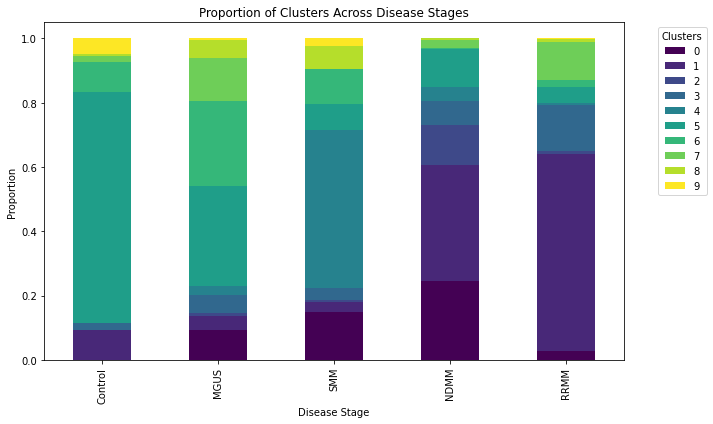

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
df = pd.read_csv('/Users/olsen/Downloads/MM_IMC_NestedClustering_per_ml.csv')

# Group by Disease_Stage and cluster, summing per 100k
grouped = df.groupby(['Disease_Stage', 'cluster'])['per 100k'].sum().reset_index()

# Calculate the total per 100k per Disease_Stage
total_per_stage = grouped.groupby('Disease_Stage')['per 100k'].transform('sum')

# Calculate proportions
grouped['proportion'] = grouped['per 100k'] / total_per_stage

# Define the desired order of Disease_Stage
order = ['Control', 'MGUS', 'SMM', 'NDMM', 'RRMM']

# Convert Disease_Stage into an ordered categorical variable
grouped['Disease_Stage'] = pd.Categorical(grouped['Disease_Stage'], categories=order, ordered=True)

# Pivot for plotting
pivot_table = grouped.pivot(index='Disease_Stage', columns='cluster', values='proportion').fillna(0)

# Sort index based on the defined order
pivot_table = pivot_table.loc[order]

# Plot stacked bar chart
pivot_table.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

# Customize labels and title
plt.title('Proportion of Clusters Across Disease Stages')
plt.ylabel('Proportion')
plt.xlabel('Disease Stage')

# Adjust legend position
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

# Improve layout
plt.tight_layout()

# Show the plot
plt.show()


Chi-square test for abundance (using per 100k):
Chi-square statistic: 41068.97
Degrees of freedom: 36
P-value: 0.00e+00


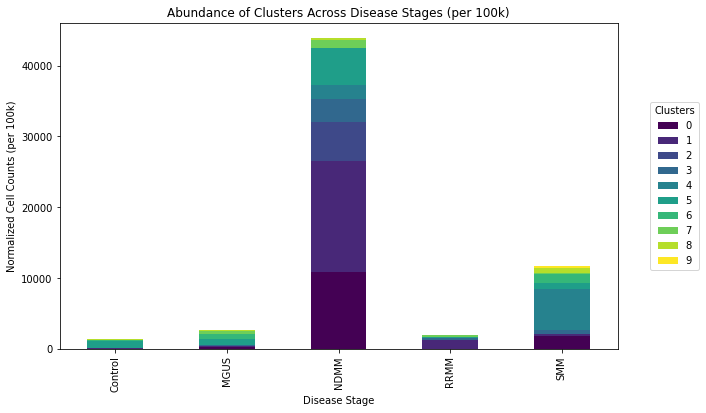

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load your dataset into a DataFrame
df = pd.read_csv('/Users/olsen/Downloads/MM_IMC_NestedClustering_per_ml.csv')

# Calculate the summed `per 100k` for each Disease_Stage and cluster
counts = df.groupby(['Disease_Stage', 'cluster'])['per 100k'].sum().unstack(fill_value=0)

# Plot the normalized `per 100k` data as a stacked bar graph
ax = counts.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

# Labeling the plot
ax.set_xlabel('Disease Stage')
ax.set_ylabel('Normalized Cell Counts (per 100k)')
ax.set_title('Abundance of Clusters Across Disease Stages (per 100k)')
ax.legend(title='Clusters', bbox_to_anchor=(1.05, 0.5), loc='center left')

# Perform a Chi-square test for abundance (using normalized data)
chi2, p, dof, expected = stats.chi2_contingency(counts)

# Print test results
print("Chi-square test for abundance (using per 100k):")
print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.2e}")


<Figure size 720x432 with 0 Axes>

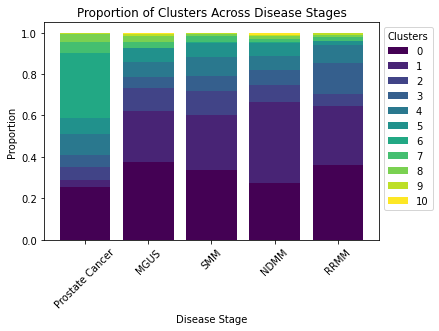

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
data = pd.read_csv("filtered_env_cells_umap.csv")

disease_order = ["Prostate Cancer", "MGUS", "SMM", "NDMM", "RRMM"]

# Count occurrences of each cluster in each diagnosis
cluster_counts = data.groupby(["Diagnosis", "leiden"]).size().unstack(fill_value=0)

# Convert to proportions
cluster_proportions = cluster_counts.div(cluster_counts.sum(axis=1), axis=0)

# Reorder the index based on the predefined order
cluster_proportions = cluster_proportions.reindex(disease_order)

# Plot
plt.figure(figsize=(10, 6))
cluster_proportions.plot(kind="bar", stacked=True, colormap="viridis", width=0.8)

plt.xlabel("Disease Stage")
plt.ylabel("Proportion")
plt.title("Proportion of Clusters Across Disease Stages")
plt.legend(title="Clusters", bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.show()

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

data = pd.read_csv("filtered_env_cells_umap.csv")

# Define the specific order for disease stages
disease_order = ["Prostate Cancer", "MGUS", "SMM", "NDMM", "RRMM"]

# Count occurrences of each cluster in each diagnosis
cluster_counts = data.groupby(["Diagnosis", "leiden"]).size().unstack(fill_value=0)

# Convert to proportions
cluster_proportions = cluster_counts.div(cluster_counts.sum(axis=1), axis=0)

# Reorder the index based on disease order
cluster_proportions = cluster_proportions.reindex(disease_order)

# Define a color palette (avoiding viridis)
colors = sns.color_palette("tab10", n_colors=11)  # Using 'tab10' for distinct colors

# Save plots into a single PDF
pdf_filename = "cluster_proportions.pdf"
with PdfPages(pdf_filename) as pdf:
    for cluster in cluster_proportions.columns:
        plt.figure(figsize=(6, 4))
        plt.bar(cluster_proportions.index, cluster_proportions[cluster], color=colors[cluster])
        
        plt.xlabel("Disease Stage")
        plt.ylabel("Proportion")
        plt.title(f"Proportion of Cluster {cluster} Across Disease Stages")
        plt.xticks(rotation=45)
        plt.ylim(0, 1)  # Normalize y-axis across all plots for consistency

        # Save the current figure to the PDF
        pdf.savefig()
        plt.close()  # Close the figure to avoid overlapping

print(f"Saved all plots to {pdf_filename}")


/var/folders/s4/06b809wn5yj090rj5zkww0qm0000gn/T/ipykernel_4496/2304461469.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("filtered_env_cells_umap.csv")


Saved all plots to cluster_proportions.pdf


/var/folders/s4/06b809wn5yj090rj5zkww0qm0000gn/T/ipykernel_4496/2572184035.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("filtered_env_cells_umap.csv")


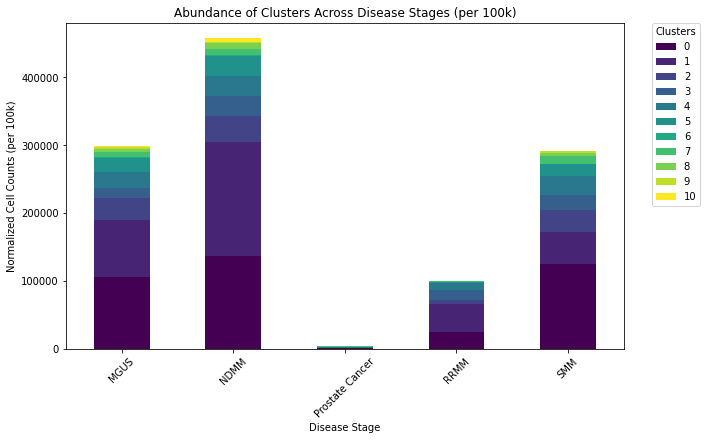

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the main dataset
df = pd.read_csv("filtered_env_cells_umap.csv")  

# Load the total cell counts per Slide_ID
total_cells_df = pd.read_csv("temp.csv")  # Adjust filename
total_cells_df.columns = ["Slide_ID", "Total_Cells"]

# Count occurrences of each cluster per Slide_ID and Diagnosis
cluster_counts = df.groupby(["Diagnosis", "Slide_ID", "leiden"]).size().reset_index(name="Count")

# Merge with total cell counts
cluster_counts = cluster_counts.merge(total_cells_df, on="Slide_ID")

# Normalize to per 100k cells
cluster_counts["Normalized_Count"] = (cluster_counts["Count"] / cluster_counts["Total_Cells"]) * 100000

# Aggregate at the Diagnosis level (sum over Slide_IDs)
final_counts = cluster_counts.groupby(["Diagnosis", "leiden"])["Normalized_Count"].sum().reset_index()

# Pivot for stacked bar chart
pivot_df = final_counts.pivot(index="Diagnosis", columns="leiden", values="Normalized_Count").fillna(0)

# Plot
pivot_df.plot(kind="bar", stacked=True, colormap="viridis", figsize=(10,6))
plt.xlabel("Disease Stage")
plt.ylabel("Normalized Cell Counts (per 100k)")
plt.title("Abundance of Clusters Across Disease Stages (per 100k)")
plt.legend(title="Clusters")
plt.xticks(rotation=45)

# Move legend to the far right
plt.legend(title="Clusters", bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.)

plt.show()


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# Load the main dataset
df = pd.read_csv("filtered_env_cells_umap.csv")  

# Load the total cell counts per Slide_ID
total_cells_df = pd.read_csv("temp.csv")  # Adjust filename
total_cells_df.columns = ["Slide_ID", "Total_Cells"]

# Count occurrences of each cluster per Slide_ID and Diagnosis
cluster_counts = df.groupby(["Diagnosis", "Slide_ID", "leiden"]).size().reset_index(name="Count")

# Merge with total cell counts
cluster_counts = cluster_counts.merge(total_cells_df, on="Slide_ID")

# Normalize to per 100k cells
cluster_counts["Normalized_Count"] = (cluster_counts["Count"] / cluster_counts["Total_Cells"]) * 100000

# Aggregate at the Diagnosis level (sum over Slide_IDs)
final_counts = cluster_counts.groupby(["Diagnosis", "leiden"])["Normalized_Count"].sum().reset_index()

# Get unique cluster labels
clusters = sorted(final_counts["leiden"].unique())

# Set consistent y-axis limit
y_max = final_counts["Normalized_Count"].max() * 1.1  # Adding 10% padding

# Save to PDF
pdf_filename = "cluster_abundance_env.pdf"  
with PdfPages(pdf_filename) as pdf:
    for cluster in clusters:
        plt.figure(figsize=(8, 5))
        
        # Filter data for the current cluster
        subset = final_counts[final_counts["leiden"] == cluster]
        
        # Bar plot
        plt.bar(subset["Diagnosis"], subset["Normalized_Count"], color=f"C{cluster % 10}")
        
        # Formatting
        plt.xlabel("Disease Stage")
        plt.ylabel("Normalized Cell Counts (per 100k)")
        plt.title(f"Cluster {cluster} Abundance Across Disease Stages")
        plt.xticks(rotation=45)
        plt.ylim(0, y_max)  # Keep consistent scale across graphs
        
        # Save the figure to the PDF
        pdf.savefig()
        plt.close()  # Close figure to free memory

print(f"PDF saved successfully: {pdf_filename}")


/var/folders/s4/06b809wn5yj090rj5zkww0qm0000gn/T/ipykernel_4496/91611816.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("filtered_env_cells_umap.csv")


PDF saved successfully: cluster_abundance_env.pdf


In [1]:
#Used to generate per 100k normalized data for wilcox tests

import pandas as pd

umap_df = pd.read_csv("/Users/olsen/Desktop/MMProject/MM_cells_umap.csv", dtype={"Slide_ID": "string"}, low_memory=False)
print(umap_df.shape)


# Load total cell counts per Slide_ID
total_cells_df = pd.read_csv("/Users/olsen/Desktop/MMProject/cellsPerSlide.csv")
total_cells_df.columns = ["Slide_ID", "Total_Cells"]


# Count occurrences of each cluster per Slide_ID and Diagnosis
cluster_counts = umap_df.groupby(["Slide_ID", "Diagnosis", "leiden"]).size().reset_index(name="cluster_count")

# Merge with total cell counts
cluster_counts = cluster_counts.merge(total_cells_df, on="Slide_ID")

# Normalize counts per 100k cells
cluster_counts["cell_per_100K"] = (cluster_counts["cluster_count"] / cluster_counts["Total_Cells"]) * 100000

# Rename columns for clarity
cluster_counts.rename(columns={
    "Diagnosis": "Disease_Stage",
    "leiden": "cluster"
}, inplace=True)

# Sort for better readability
cluster_counts = cluster_counts.sort_values(["Slide_ID", "cluster"])

# Save to CSV
csv_filename = "MM_cluster_abundance_per_slide.csv"
cluster_counts.to_csv(csv_filename, index=False)

print(f"CSV saved successfully: {csv_filename}")


(9625, 6)
CSV saved successfully: MM_cluster_abundance_per_slide.csv
